## Importing Required Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [29]:
cus_data = pd.read_csv('mall_customers.csv')
cus_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [30]:
cus_data.describe()
cus_data.head()
cus_data.iloc[:, 2:]

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [31]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(data):
    scaler = StandardScaler()
    data = data.iloc[:, 2:]
    scaled_data = scaler.fit_transform(data)
    return scaled_data

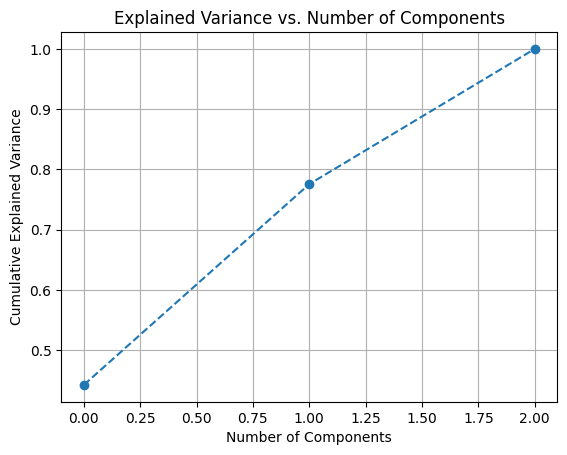

In [32]:
pca = PCA()
scaled_data = preprocess_data(cus_data)
pca.fit(scaled_data)
explained_variance = pca.explained_variance_ratio_
plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid()
plt.show()


In [33]:
pca = PCA(n_components=2)
scaled_data = preprocess_data(cus_data)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data=pca_data, columns=['Principal Component 1', 'Principal Component 2'])
pca_df.head()

,Principal Component 1,Principal Component 2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


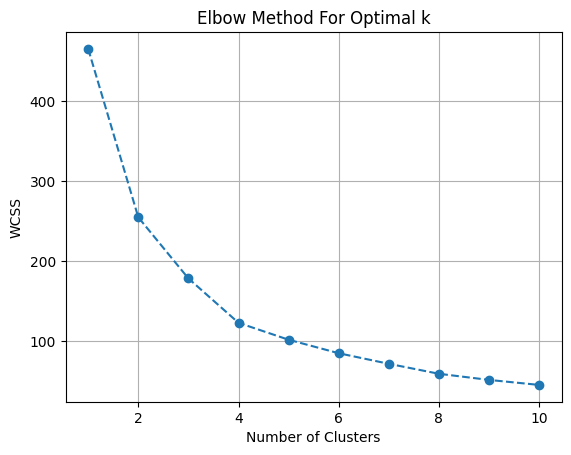

In [34]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.grid()
plt.show()

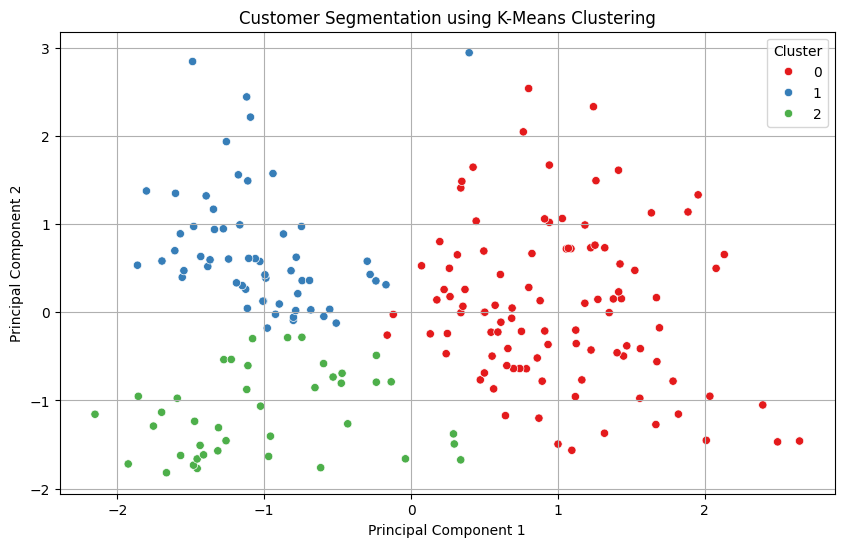

In [35]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(pca_df)
pca_df['Cluster'] = clusters
plt.figure(figsize=(10, 6))
sn.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df, palette='Set1')
plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid()
plt.show()

In [36]:
cus_data = pd.concat([cus_data, pca_df], axis=1)

In [37]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=['age', 'annual_income', 'spending_score']
)
print(loadings)

                     PC1       PC2
age             0.706382  0.030141
annual_income  -0.048024  0.998832
spending_score -0.706199 -0.037775


In [40]:
cus_data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Principal Component 1,Principal Component 2,Cluster
0,1,Male,19,15,39,-0.615720,-1.763481,2
1,2,Male,21,15,81,-1.665793,-1.820747,2
2,3,Female,20,16,6,0.337862,-1.674799,2
3,4,Female,23,16,77,-1.456573,-1.772430,2
4,5,Female,31,17,40,-0.038465,-1.662740,2
...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,-1.093705,2.215577,1
196,197,Female,45,126,28,0.800448,2.540748,0
197,198,Male,32,126,74,-1.119709,2.445169,1
198,199,Male,32,137,18,0.395411,2.946665,1


In [ ]:
cus_data_num = cus_data.loc[:, ['age', 'annual_income', 'spending_score', 'Cluster']].groupby('Cluster')
cus_data_cat = cus_data.loc[:, ['gender', 'Cluster']].groupby('Cluster')

SyntaxError: invalid syntax (3302615874.py, line 1)